In [1]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

conn = pyodbc.connect(
    'DRIVER={SQL Server};'
    'SERVER=DESKTOP-NO8NMT1\\MSSQLSERVER01;'
    'DATABASE=OlistDB;'
    'Trusted_Connection=yes;'
)

print("Connected Successfully!")

Connected Successfully!


## Top 10 States by Revenue

C:\Users\achel\AppData\Local\Temp\ipykernel_15532\533771494.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


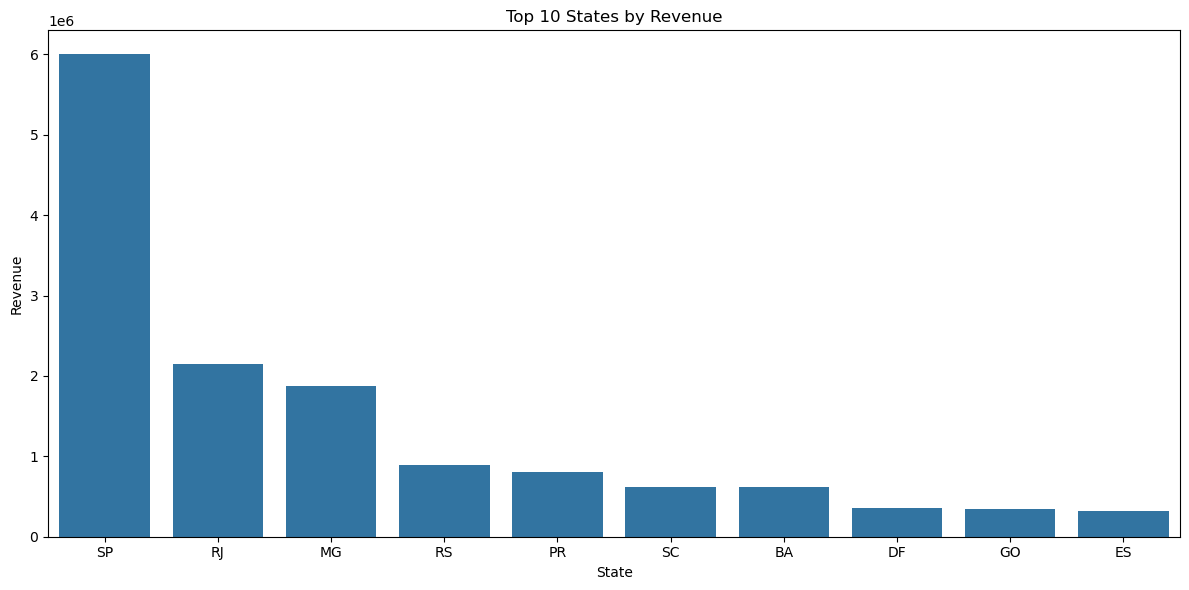

In [2]:
query = """
SELECT TOP 10
c.customer_state,
SUM(op.payment_value) AS Revenue
FROM customers c
JOIN orders o
ON c.customer_id = o.customer_id
JOIN order_payments op
ON o.order_id = op.order_id
GROUP BY c.customer_state
ORDER BY Revenue DESC
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(12,6))
sns.barplot(data=df,
            x='customer_state',
            y='Revenue')

plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')
plt.tight_layout()

plt.savefig('revenue_by_state.png')
plt.show()

## Top Product Categories

C:\Users\achel\AppData\Local\Temp\ipykernel_15532\3306516323.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


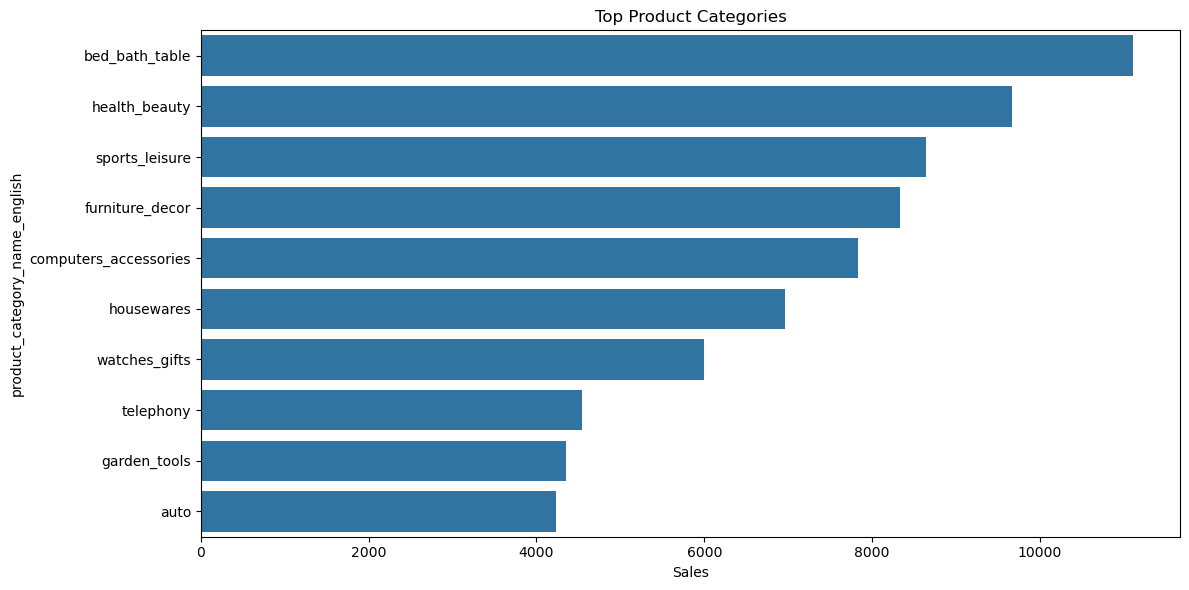

In [3]:
query = """
SELECT TOP 10
ct.product_category_name_english,
COUNT(*) AS Sales
FROM order_items oi
JOIN products p
ON oi.product_id = p.product_id
JOIN category_translation ct
ON p.product_category_name =
ct.product_category_name
GROUP BY ct.product_category_name_english
ORDER BY Sales DESC
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(12,6))
sns.barplot(
    data=df,
    x='Sales',
    y='product_category_name_english'
)

plt.title('Top Product Categories')
plt.tight_layout()

plt.savefig('top_categories.png')
plt.show()

## Payment Method Distribution

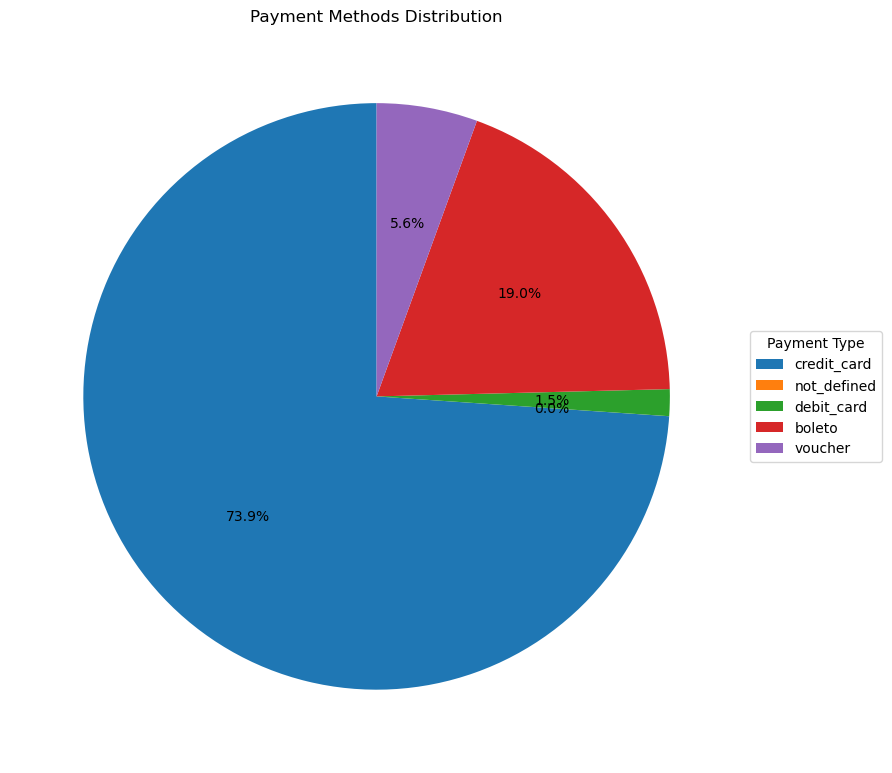

In [7]:
query = """
SELECT
    payment_type,
    COUNT(*) AS Transactions
FROM order_payments
GROUP BY payment_type
"""

fig, ax = plt.subplots(figsize=(9, 9))

wedges, texts, autotexts = ax.pie(
    df['Transactions'],
    autopct='%1.1f%%',
    startangle=90
)

ax.legend(
    wedges,
    df['payment_type'],
    title='Payment Type',
    loc='center left',
    bbox_to_anchor=(1, 0.5)
)

ax.set_title('Payment Methods Distribution')
plt.tight_layout()
plt.show()

## Review Score Distribution

C:\Users\achel\AppData\Local\Temp\ipykernel_15532\908966913.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


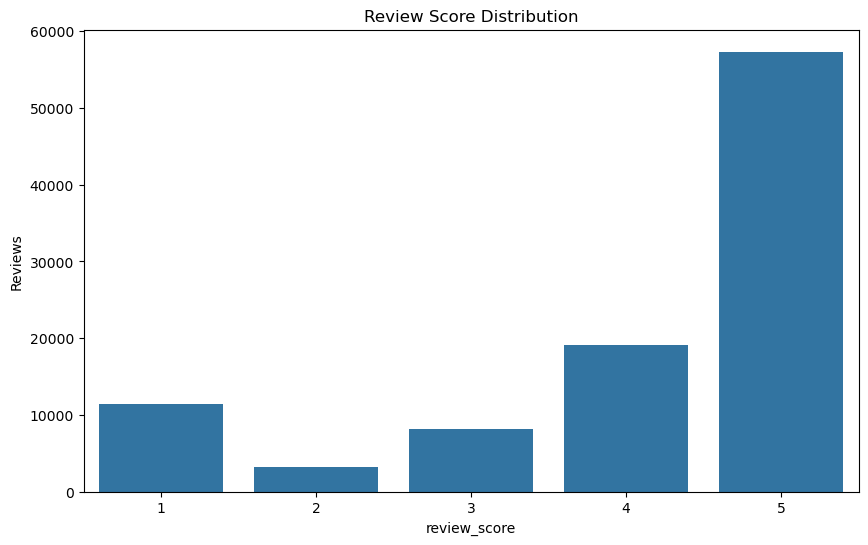

In [8]:
query = """
SELECT
review_score,
COUNT(*) AS Reviews
FROM order_reviews
GROUP BY review_score
ORDER BY review_score
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='review_score',
    y='Reviews'
)

plt.title('Review Score Distribution')

plt.savefig('review_scores.png')
plt.show()

## Monthly Revenue Trend

C:\Users\achel\AppData\Local\Temp\ipykernel_15532\1658738867.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


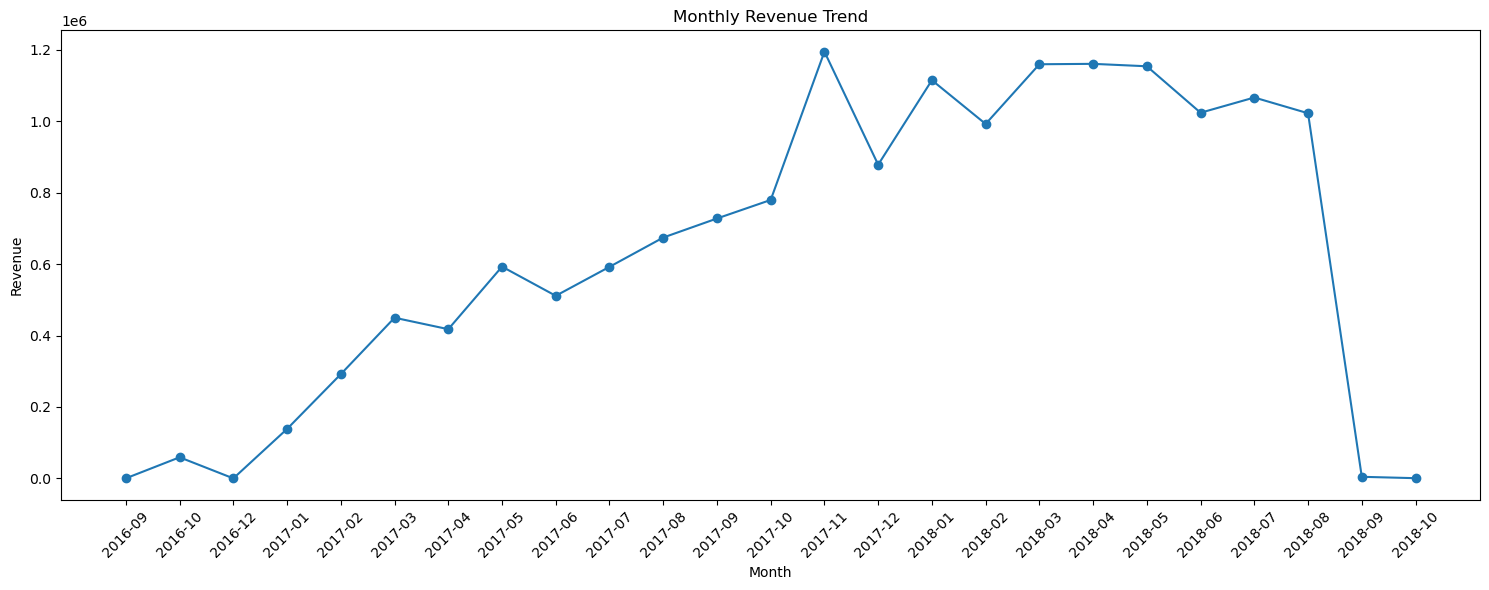

In [9]:
query = """
SELECT
FORMAT(order_purchase_timestamp,'yyyy-MM') AS Month,
SUM(payment_value) AS Revenue
FROM orders o
JOIN order_payments op
ON o.order_id = op.order_id
GROUP BY FORMAT(order_purchase_timestamp,'yyyy-MM')
ORDER BY Month
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(15,6))

plt.plot(
    df['Month'],
    df['Revenue'],
    marker='o'
)

plt.xticks(rotation=45)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')

plt.tight_layout()

plt.savefig('monthly_revenue.png')
plt.show()

## Customer Satisfaction by State

C:\Users\achel\AppData\Local\Temp\ipykernel_15532\4108544003.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


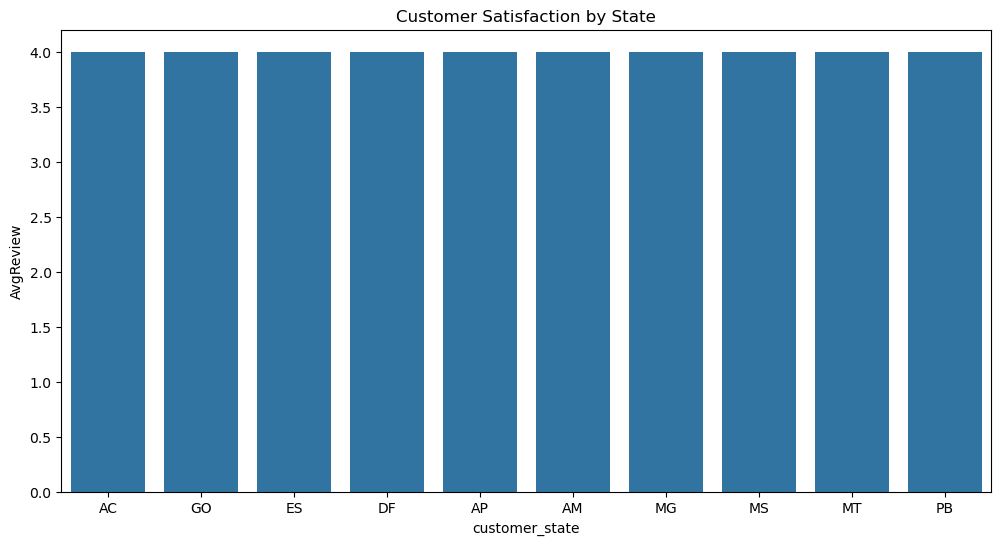

In [10]:
query = """
SELECT TOP 10
c.customer_state,
AVG(r.review_score) AS AvgReview
FROM customers c
JOIN orders o
ON c.customer_id=o.customer_id
JOIN order_reviews r
ON o.order_id=r.order_id
GROUP BY c.customer_state
ORDER BY AvgReview DESC
"""

df = pd.read_sql(query, conn)

plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x='customer_state',
    y='AvgReview'
)

plt.title('Customer Satisfaction by State')

plt.savefig('customer_satisfaction.png')

plt.show()